# ZIP demo for a validation prompt

This notebook runs ZIP on a validation prompt with a known expected keyword.

In [1]:
import os
import sys
import re
import importlib.util
from pathlib import Path

import pandas as pd
from openai import OpenAI

# Set your OpenAI API key here.
os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_API_KEY"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

CURRENT_DIR = Path.cwd().resolve()

def find_src_dir(start_dir):
    for parent in [start_dir] + list(start_dir.parents):
        src = parent / "src"
        if src.exists() and (src / "creating_perturbations.py").exists():
            return src
    raise FileNotFoundError("Could not find src/creating_perturbations.py")

SRC_DIR = find_src_dir(CURRENT_DIR)
REPO_ROOT = SRC_DIR.parent
sys.path.insert(0, str(SRC_DIR))

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

creating_perturbations = load_module("creating_perturbations", SRC_DIR / "creating_perturbations.py")
stat_calc = load_module("stat_calc", SRC_DIR / "stat.py")
visualization = load_module("visualization", SRC_DIR / "visualization.py")

WORK_DIR = REPO_ROOT / "outputs" / "validation_prompt"
WORK_DIR.mkdir(parents=True, exist_ok=True)

# choose the model for perturbation generation and answer generation.
MODEL_PERT = "gpt-4"
MODEL_ANS = "gpt-4o-mini"

print("REPO_ROOT:", REPO_ROOT)
print("SRC_DIR:", SRC_DIR)
print("WORK_DIR:", WORK_DIR)

I0000 00:00:1779139008.305290 3877720 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779139008.306337 3877720 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779139009.354145 3877720 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779139009.354768 3877720 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


REPO_ROOT: /local/home/ngsadr/Projects/clean_scripts
SRC_DIR: /local/home/ngsadr/Projects/clean_scripts/src
WORK_DIR: /local/home/ngsadr/Projects/clean_scripts/outputs/validation_prompt


## Set the validation prompt and keyword

In [2]:
VALIDATION_PROMPT = "Say the word green"
KEYWORD = "green"

N_PER_METHOD = 2      # up to 2 deletion + 2 synonym + 2 co-hyponym per token
ORIGINAL_REPS = 5     # repeated original prompt runs for baseline variation
TEMPERATURE = 0.5

tokens = VALIDATION_PROMPT.split()

## Create perturbations 

In [3]:
perturbations_file = WORK_DIR / "perturbations.csv"

perturbations_df = creating_perturbations.save_perturbations(
    prompt=VALIDATION_PROMPT,
    output_path=str(perturbations_file),
    model=MODEL_PERT,
    n_per_method=N_PER_METHOD,
    validate=True,
)

perturbations_df

,token_index,token,0,1,2,3,4
0,0,Say,the word green,Utter the word green.,Speak the word green.,State the word green.,Announce the word green.
1,2,word,Say the term green.,Say the phrase green.,Say the name green.,NaN,NaN
2,3,green,Say the word,Say the word verdant.,Say the word emerald.,Say the word blue.,Say the word red.


## Query the model and compute disagreement scores 

In [4]:
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

def query_model(prompt, model=MODEL_ANS, temperature=TEMPERATURE):
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt + " Do not output more than one word."}],
        temperature=temperature,
    )
    return response.choices[0].message.content.strip()

def first_clean_word(text):
    words = re.findall(r"\b\w+\b", str(text).lower())
    return words[0] if words else ""

def has_keyword(response, keyword=KEYWORD):
    return keyword.lower() in first_clean_word(response)

original_rows = []
for rep in range(ORIGINAL_REPS):
    response = query_model(VALIDATION_PROMPT)
    original_rows.append({
        "rep": rep,
        "prompt": VALIDATION_PROMPT,
        "response": response,
        "keyword_match": int(has_keyword(response)),
    })

original_df = pd.DataFrame(original_rows)
original_df.to_csv(WORK_DIR / "original_validation_responses.csv", index=False)
original_df

,rep,prompt,response,keyword_match
0,0,Say the word green,Green,1
1,1,Say the word green,Green,1
2,2,Say the word green,Green,1
3,3,Say the word green,Green,1
4,4,Say the word green,Green,1


In [5]:
baseline_match = int(original_df.loc[0, "keyword_match"])

original_disagreements = [
    int(match != baseline_match)
    for match in original_df["keyword_match"].tolist()[1:]
]

original_disagreements_file = WORK_DIR / "original_disagreements.csv"
pd.DataFrame({"original_disagreement": original_disagreements}).to_csv(
    original_disagreements_file,
    index=False,
)

original_disagreements

[0, 0, 0, 0]

In [6]:
alt_cols = [c for c in perturbations_df.columns if c not in {"token_index", "token"}]
detail_rows = []

for _, row in perturbations_df.iterrows():
    token_index = int(row["token_index"])
    token = str(row["token"])

    for alt_col in alt_cols:
        perturbation = row.get(alt_col)
        if pd.isna(perturbation) or str(perturbation).strip() == "":
            continue

        perturbation = str(perturbation).strip()
        response = query_model(perturbation)
        keyword_match = int(has_keyword(response))

        detail_rows.append({
            "token_index": token_index,
            "token": token,
            "alternative_index": alt_col,
            "perturbation": perturbation,
            "response": response,
            "keyword_match": keyword_match,
            "original_keyword_match": baseline_match,
            "disagreement": int(keyword_match != baseline_match),
        })

details_df = pd.DataFrame(detail_rows)
zip_details_file = WORK_DIR / "zip_details.csv"
details_df.to_csv(zip_details_file, index=False)
details_df

,token_index,token,alternative_index,perturbation,response,keyword_match,original_keyword_match,disagreement
0,0,Say,0,the word green,Emerald,0,1,1
1,0,Say,1,Utter the word green.,Green.,1,1,0
2,0,Say,2,Speak the word green.,Green.,1,1,0
3,0,Say,3,State the word green.,Green,1,1,0
4,0,Say,4,Announce the word green.,Green.,1,1,0
5,2,word,0,Say the term green.,Green.,1,1,0
6,2,word,1,Say the phrase green.,Green.,1,1,0
7,2,word,2,Say the name green.,Green.,1,1,0
8,3,green,0,Say the word,Word.,0,1,1
9,3,green,1,Say the word verdant.,Verdant.,0,1,1


## Compute ZIP scores

In [7]:
zip_df = (
    details_df.groupby(["token_index", "token"], as_index=False)
    .agg(
        zip_score=("disagreement", lambda x: 100 * x.mean()),
        n_alternatives=("disagreement", "count"),
    )
)

zip_scores_file = WORK_DIR / "zip_scores.csv"
zip_df.to_csv(zip_scores_file, index=False)
zip_df.sort_values("zip_score", ascending=False)

,token_index,token,zip_score,n_alternatives
2,3,green,100.0,5
0,0,Say,20.0,5
1,2,word,0.0,3


## Run significance testing

In [8]:
stats_df = stat_calc.compute_significance(
    zip_details_file=str(zip_details_file),
    original_disagreements_file=str(original_disagreements_file),
    output_dir=str(WORK_DIR),
    alpha=0.05,
)

significant_tokens_file = WORK_DIR / "significant_tokens.txt"

stats_with_scores = zip_df.merge(stats_df, on=["token_index", "token"], how="left")
stats_with_scores.sort_values("zip_score", ascending=False)

,token_index,token,zip_score,n_alternatives,mean_perturbed_disagreement,mean_original_disagreement,statistic,p_value,significant
2,3,green,100.0,5,1.0,0.0,2.449490,0.014306,True
0,0,Say,20.0,5,0.2,0.0,0.489898,0.624206,False
1,2,word,0.0,3,0.0,0.0,0.000000,1.000000,False


## Visualize prompt heatmap

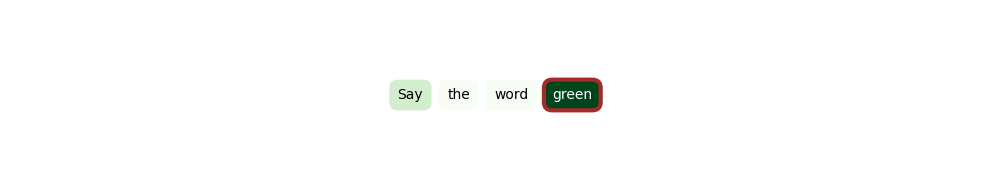

In [9]:
fig = visualization.plot_zip_heatmap(
    prompt=VALIDATION_PROMPT,
    zip_scores_file=str(zip_scores_file),
    significant_tokens_file=str(significant_tokens_file),
    output_path=str(WORK_DIR / "validation_prompt_zip_heatmap.png"),
    show=True,
)